# Comprehensive Machine Learning Project Analysis

## Tree-Based Learners: Decision Trees, Random Forests, and Extra Trees

This notebook provides a comprehensive analysis of a custom machine learning implementation comparing Decision Trees, Random Forests, and Extra Trees with scikit-learn implementations across Iris and Wine datasets.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.datasets import load_iris, load_wine
import warnings

warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 1. Load and Explore Project Data

In [2]:
# Load datasets
iris = load_iris()
wine = load_wine()

# Create DataFrames
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target

print("=" * 80)
print("IRIS DATASET EXPLORATION")
print("=" * 80)
print(f"Shape: {iris_df.shape}")
print(f"\nFirst 5 rows:\n{iris_df.head()}")
print(f"\nData types:\n{iris_df.dtypes}")
print(f"\nMissing values:\n{iris_df.isnull().sum()}")
print(f"\nTarget distribution:\n{iris_df['target'].value_counts().sort_index()}")

print("\n" + "=" * 80)
print("WINE DATASET EXPLORATION")
print("=" * 80)
print(f"Shape: {wine_df.shape}")
print(f"\nFirst 5 rows:\n{wine_df.head()}")
print(f"\nData types:\n{wine_df.dtypes}")
print(f"\nMissing values:\n{wine_df.isnull().sum()}")
print(f"\nTarget distribution:\n{wine_df['target'].value_counts().sort_index()}")

IRIS DATASET EXPLORATION
Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Target distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64



## 2. Descriptive Statistics and Summary

In [3]:
def analyze_descriptive_stats(df, dataset_name):
    print(f"\n{'='*80}")
    print(f"DESCRIPTIVE STATISTICS - {dataset_name.upper()}")
    print(f"{'='*80}")
    
    stats_df = df.describe().T
    print(f"\n{stats_df}")
    
    print(f"\n\nSkewness Analysis:")
    skewness = df.iloc[:, :-1].skew()
    print(skewness)
    
    print(f"\n\nKurtosis Analysis:")
    kurtosis = df.iloc[:, :-1].kurtosis()
    print(kurtosis)
    
    print(f"\n\nClass Balance:")
    class_dist = df['target'].value_counts().sort_index()
    class_pct = (class_dist / len(df) * 100).round(2)
    balance_df = pd.DataFrame({
        'Class': class_dist.index,
        'Count': class_dist.values,
        'Percentage': class_pct.values
    })
    print(balance_df)
    
    return stats_df, balance_df

iris_stats, iris_balance = analyze_descriptive_stats(iris_df, "Iris")
wine_stats, wine_balance = analyze_descriptive_stats(wine_df, "Wine")


DESCRIPTIVE STATISTICS - IRIS

                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5
target             150.0  1.000000  0.819232  0.0  0.0  1.00  2.0  2.0


Skewness Analysis:
sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64


Kurtosis Analysis:
sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64


Class Balance:
   Class  Count  Percentage
0      0     50       33.33
1      1     50       33.33
2      2     50       33.33

DESCRIPTIVE STATISTICS - WINE

                              count        mean         std     min  

## 3. Data Visualization and EDA

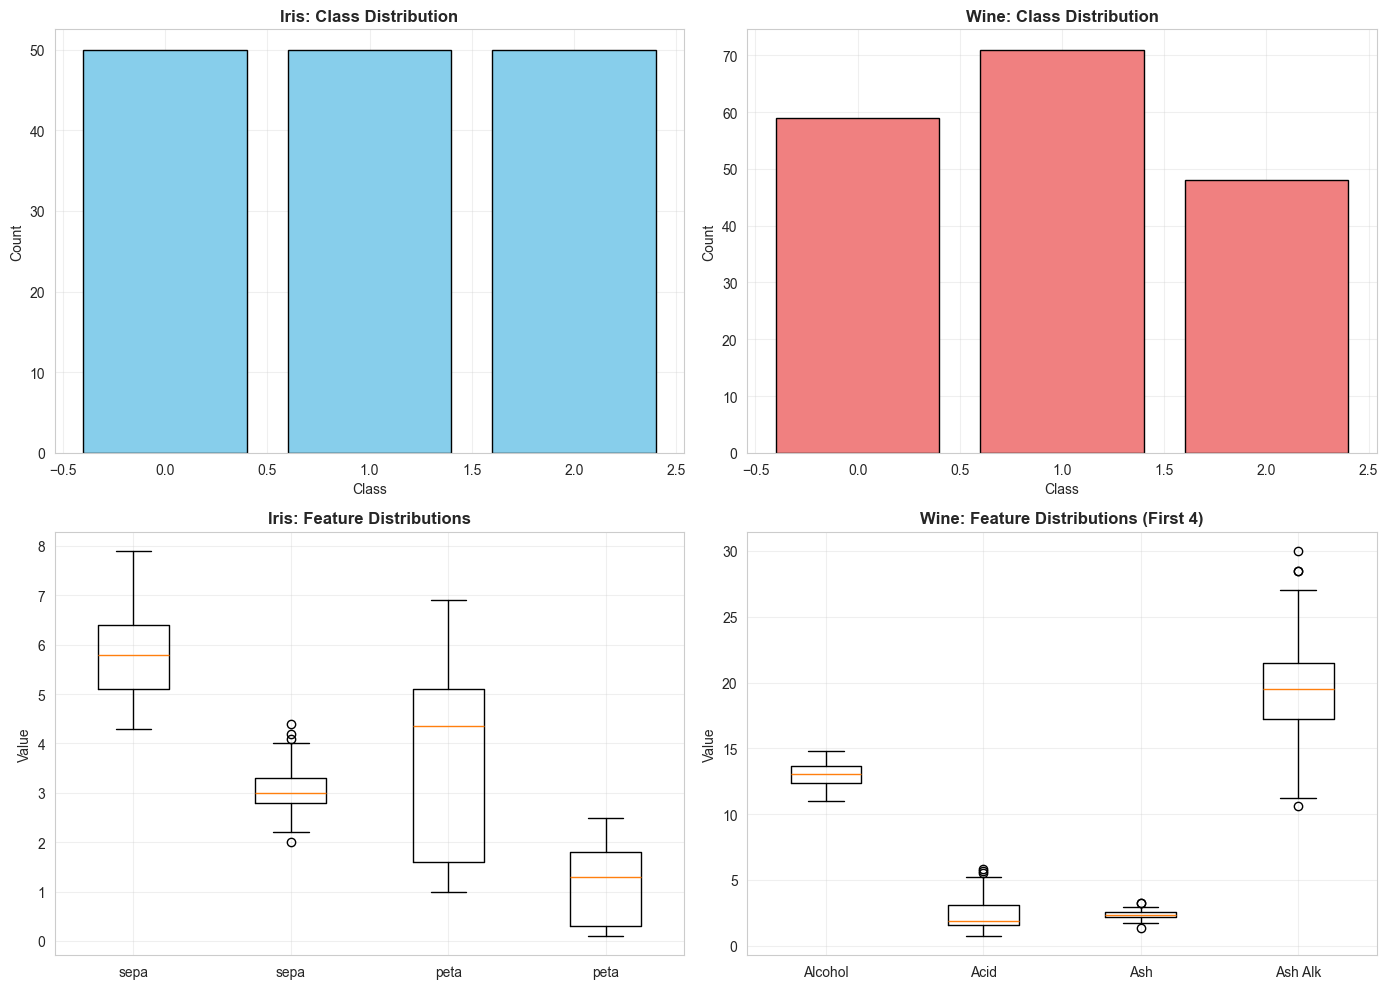

✓ Distribution plots created


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Iris class distribution
iris_classes = iris_df['target'].value_counts().sort_index()
axes[0, 0].bar(iris_classes.index, iris_classes.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Iris: Class Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# Wine class distribution
wine_classes = wine_df['target'].value_counts().sort_index()
axes[0, 1].bar(wine_classes.index, wine_classes.values, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Wine: Class Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(alpha=0.3)

# Iris feature distributions
iris_features = iris_df.iloc[:, :-1]
axes[1, 0].boxplot(iris_features, labels=[f.split()[0][:4] for f in iris.feature_names])
axes[1, 0].set_title('Iris: Feature Distributions', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Value')
axes[1, 0].grid(alpha=0.3)

# Wine feature distributions
wine_features = wine_df.iloc[:, :-1]
axes[1, 1].boxplot(wine_features.iloc[:, :4], labels=['Alcohol', 'Acid', 'Ash', 'Ash Alk'])
axes[1, 1].set_title('Wine: Feature Distributions (First 4)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Distribution plots created")

## 4. Correlation and Feature Relationships

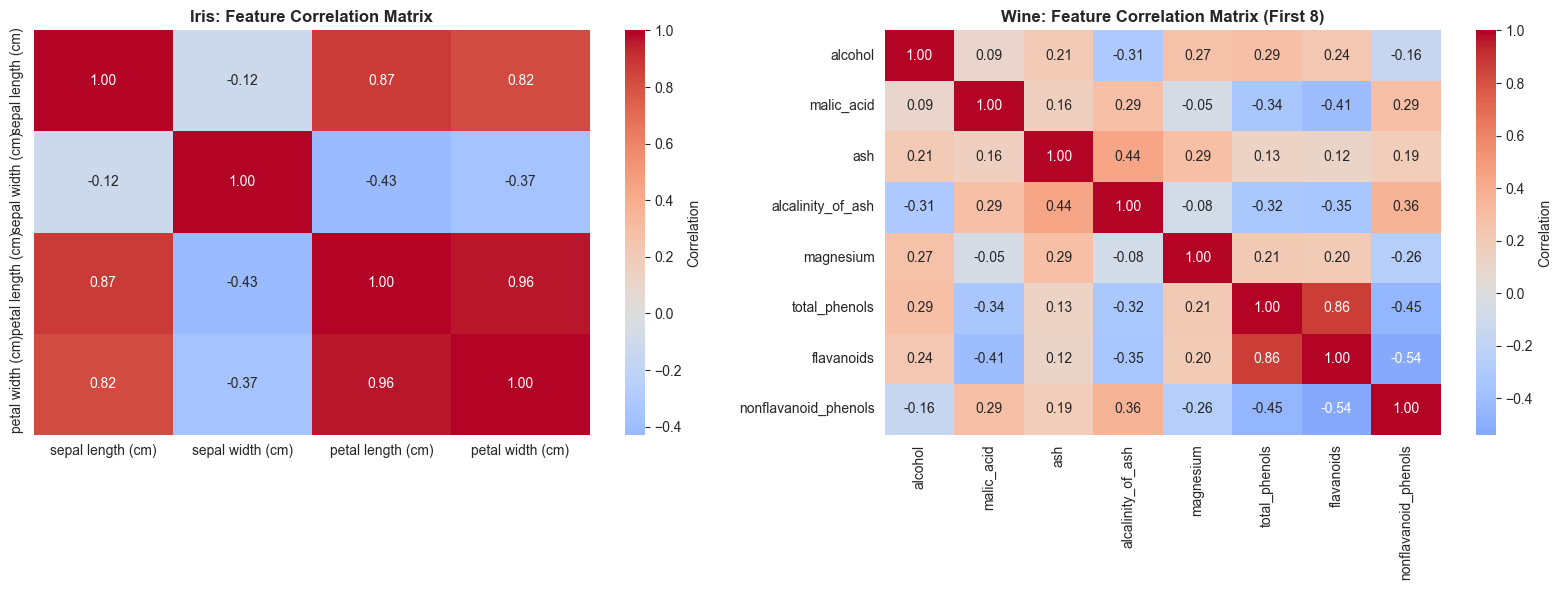


High Correlations (|r| > 0.7) - IRIS:
  sepal length (cm) <-> petal length (cm): 0.872
  sepal length (cm) <-> petal width (cm): 0.818
  petal length (cm) <-> petal width (cm): 0.963

High Correlations (|r| > 0.7) - WINE:
  total_phenols <-> flavanoids: 0.865


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Iris correlations
iris_corr = iris_df.iloc[:, :-1].corr()
sns.heatmap(iris_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Iris: Feature Correlation Matrix', fontsize=12, fontweight='bold')

# Wine correlations (first 8 features for clarity)
wine_corr = wine_df.iloc[:, :8].corr()
sns.heatmap(wine_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Wine: Feature Correlation Matrix (First 8)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print high correlations
print("\nHigh Correlations (|r| > 0.7) - IRIS:")
for i in range(len(iris_corr.columns)):
    for j in range(i+1, len(iris_corr.columns)):
        if abs(iris_corr.iloc[i, j]) > 0.7:
            print(f"  {iris_corr.columns[i]} <-> {iris_corr.columns[j]}: {iris_corr.iloc[i, j]:.3f}")

print("\nHigh Correlations (|r| > 0.7) - WINE:")
for i in range(len(wine_corr.columns)):
    for j in range(i+1, len(wine_corr.columns)):
        if abs(wine_corr.iloc[i, j]) > 0.7:
            print(f"  {wine_corr.columns[i][:15]} <-> {wine_corr.columns[j][:15]}: {wine_corr.iloc[i, j]:.3f}")

## 5. Run Model Experiments and Compare Performance

In [6]:
import subprocess
import sys

# Run the main experiment script
result = subprocess.run(
    [sys.executable, 'run_experiments.py', '--max-depth', '12', '--n-estimators', '80', '--table-format', 'github'],
    cwd='.',
    capture_output=True,
    text=True
)

print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)


                    TREE-BASED LEARNERS: CUSTOM IMPLEMENTATIONS vs SCIKIT-LEARN                     


ðŸ“Š Dataset: Iris
   â€¢ Total samples: 150
   â€¢ Train/Test split: 112/38
   â€¢ Features: 4
   â€¢ Classes: 3
   â€¢ Class imbalance ratio: 1.03
   â€¢ Class separability score: 4.7095

ðŸ“ˆ Performance Metrics:
| Model                 |   Accuracy |     F1 |   AUROC |
|-----------------------|------------|--------|---------|
| Custom Decision Tree  |     0.9737 | 0.9732 |  1.0000 |
| Custom Random Forest  |     0.9737 | 0.9732 |  1.0000 |
| Custom Extra Trees    |     1.0000 | 1.0000 |  1.0000 |
| sklearn Decision Tree |     0.9737 | 0.9732 |  0.9792 |
| sklearn Random Forest |     0.9474 | 0.9459 |  1.0000 |
| sklearn Extra Trees   |     1.0000 | 1.0000 |  1.0000 |

   Summary:
   â€¢ Best accuracy: 1.0000
   â€¢ Mean accuracy: 0.9781
   â€¢ Accuracy std dev: 0.0181

   Decision Tree Comparison:
   â€¢ Custom:  0.9737
   â€¢ Sklearn: 0.9737
   â€¢ Difference: +0.0000

   Random

## 6. Cross-Validation and Model Robustness Analysis

In [11]:
from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.ensemble import RandomForestClassifier as SkRF, ExtraTreesClassifier as SkET
import sys
import importlib

# Remove cached modules to force reimport
if 'custom' in sys.modules:
    del sys.modules['custom']
if 'custom.tree' in sys.modules:
    del sys.modules['custom.tree']
if 'custom.ensemble' in sys.modules:
    del sys.modules['custom.ensemble']

sys.path.insert(0, '.')

from custom.tree import DecisionTreeClassifier as CustomDT
from custom.ensemble import RandomForestClassifier as CustomRF, ExtraTreesClassifier as CustomET

def perform_cv_analysis(X, y, dataset_name):
    """Perform 5-fold cross-validation analysis."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    models = {
        'Custom Decision Tree': CustomDT(max_depth=12, min_samples_split=4),
        'Sklearn Decision Tree': SkDT(max_depth=12, min_samples_split=4),
        'Custom Random Forest': CustomRF(n_estimators=80, max_depth=12),
        'Sklearn Random Forest': SkRF(n_estimators=80, max_depth=12),
        'Custom Extra Trees': CustomET(n_estimators=80, max_depth=12),
        'Sklearn Extra Trees': SkET(n_estimators=80, max_depth=12),
    }
    
    results = {}
    
    for model_name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        results[model_name] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores
        }
    
    return pd.DataFrame(results).T

# Perform CV analysis
iris_X = iris_df.iloc[:, :-1].values
iris_y = iris_df['target'].values
wine_X = wine_df.iloc[:, :-1].values
wine_y = wine_df['target'].values

iris_cv = perform_cv_analysis(iris_X, iris_y, "Iris")
wine_cv = perform_cv_analysis(wine_X, wine_y, "Wine")

print("\n" + "="*80)
print("IRIS - 5-FOLD CROSS-VALIDATION RESULTS")
print("="*80)
print(iris_cv[['mean', 'std']].round(4))

print("\n" + "="*80)
print("WINE - 5-FOLD CROSS-VALIDATION RESULTS")
print("="*80)
print(wine_cv[['mean', 'std']].round(4))


IRIS - 5-FOLD CROSS-VALIDATION RESULTS
                           mean       std
Custom Decision Tree   0.946667  0.033993
Sklearn Decision Tree  0.953333   0.01633
Custom Random Forest   0.953333  0.033993
Sklearn Random Forest  0.953333  0.033993
Custom Extra Trees     0.953333  0.033993
Sklearn Extra Trees    0.953333  0.049889

WINE - 5-FOLD CROSS-VALIDATION RESULTS
                           mean       std
Custom Decision Tree       0.91  0.033317
Sklearn Decision Tree  0.899206   0.05214
Custom Random Forest   0.960317  0.038852
Sklearn Random Forest   0.98873  0.013805
Custom Extra Trees     0.948889  0.049305
Sklearn Extra Trees     0.98873  0.013805


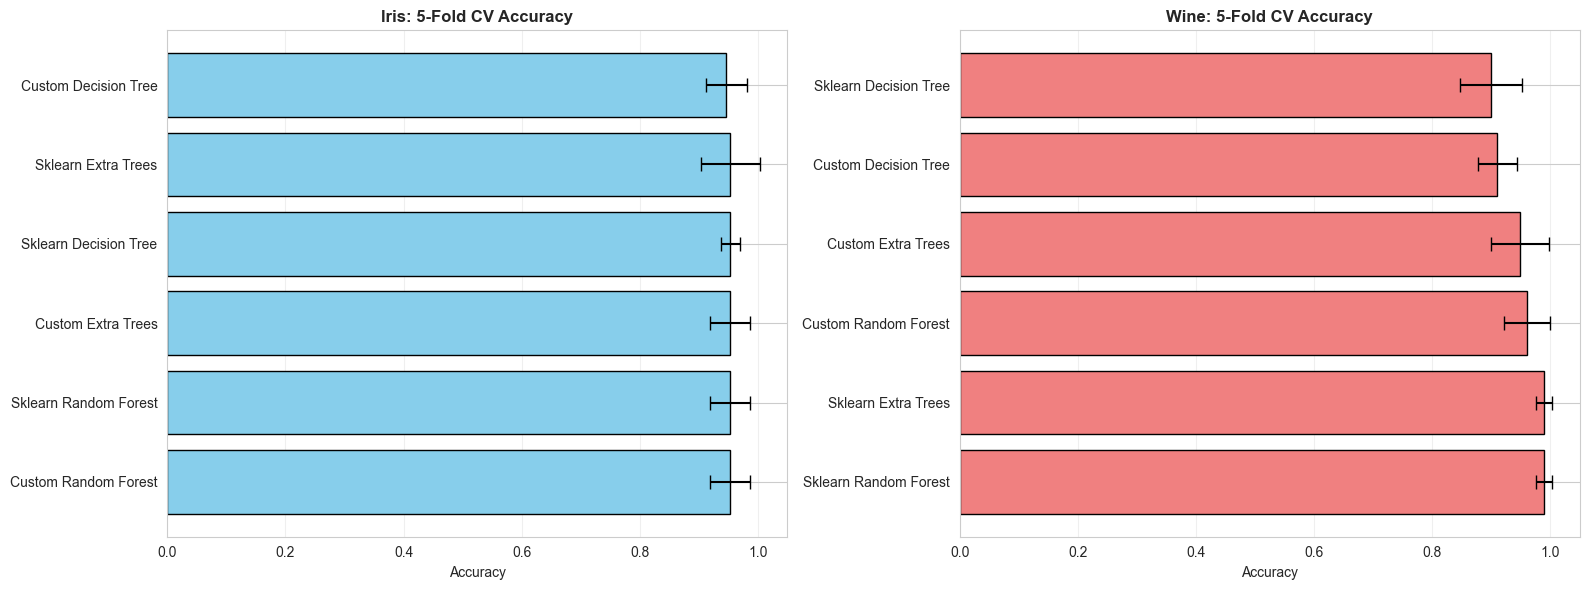

✓ Cross-validation visualization completed


In [12]:
# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Iris CV visualization
iris_cv_plot = iris_cv[['mean', 'std']].sort_values('mean', ascending=False)
axes[0].barh(range(len(iris_cv_plot)), iris_cv_plot['mean'], 
             xerr=iris_cv_plot['std'], capsize=5, color='skyblue', edgecolor='black')
axes[0].set_yticks(range(len(iris_cv_plot)))
axes[0].set_yticklabels(iris_cv_plot.index)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Iris: 5-Fold CV Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.05)
axes[0].grid(alpha=0.3, axis='x')

# Wine CV visualization
wine_cv_plot = wine_cv[['mean', 'std']].sort_values('mean', ascending=False)
axes[1].barh(range(len(wine_cv_plot)), wine_cv_plot['mean'],
             xerr=wine_cv_plot['std'], capsize=5, color='lightcoral', edgecolor='black')
axes[1].set_yticks(range(len(wine_cv_plot)))
axes[1].set_yticklabels(wine_cv_plot.index)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Wine: 5-Fold CV Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 1.05)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Cross-validation visualization completed")

## 7. Statistical Testing: Custom vs Sklearn Models

In [13]:
def statistical_significance_tests(cv_results, dataset_name):
    """Perform statistical tests comparing custom vs sklearn models."""
    print(f"\n{'='*80}")
    print(f"STATISTICAL SIGNIFICANCE TESTS - {dataset_name.upper()}")
    print(f"{'='*80}")
    
    model_pairs = [
        ('Custom Decision Tree', 'Sklearn Decision Tree'),
        ('Custom Random Forest', 'Sklearn Random Forest'),
        ('Custom Extra Trees', 'Sklearn Extra Trees'),
    ]
    
    results = []
    for custom, sklearn in model_pairs:
        custom_scores = cv_results.loc[custom, 'scores']
        sklearn_scores = cv_results.loc[sklearn, 'scores']
        
        # Paired t-test
        t_stat, p_value = stats.ttest_rel(custom_scores, sklearn_scores)
        
        # Wilcoxon signed-rank test (non-parametric alternative)
        w_stat, w_pval = stats.wilcoxon(custom_scores, sklearn_scores)
        
        mean_diff = custom_scores.mean() - sklearn_scores.mean()
        
        results.append({
            'Comparison': f"{custom.split()[1]} Tree",
            'T-Statistic': t_stat,
            'P-Value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No',
            'Mean Diff': mean_diff,
            'Wilcoxon P': w_pval,
        })
    
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    return results_df

iris_tests = statistical_significance_tests(iris_cv, "Iris")
wine_tests = statistical_significance_tests(wine_cv, "Wine")


STATISTICAL SIGNIFICANCE TESTS - IRIS
   Comparison  T-Statistic  P-Value Significant     Mean Diff  Wilcoxon P
Decision Tree    -0.534522 0.621308          No -6.666667e-03         1.0
  Random Tree          NaN      NaN          No  0.000000e+00         1.0
   Extra Tree     0.000000 1.000000          No  1.110223e-16         1.0

STATISTICAL SIGNIFICANCE TESTS - WINE
   Comparison  T-Statistic  P-Value Significant  Mean Diff  Wilcoxon P
Decision Tree     0.564485 0.602575          No   0.010794       0.875
  Random Tree    -1.815505 0.143625          No  -0.028413       0.250
   Extra Tree    -1.861508 0.136163          No  -0.039841       0.250


## 8. Hyperparameter Sensitivity Analysis

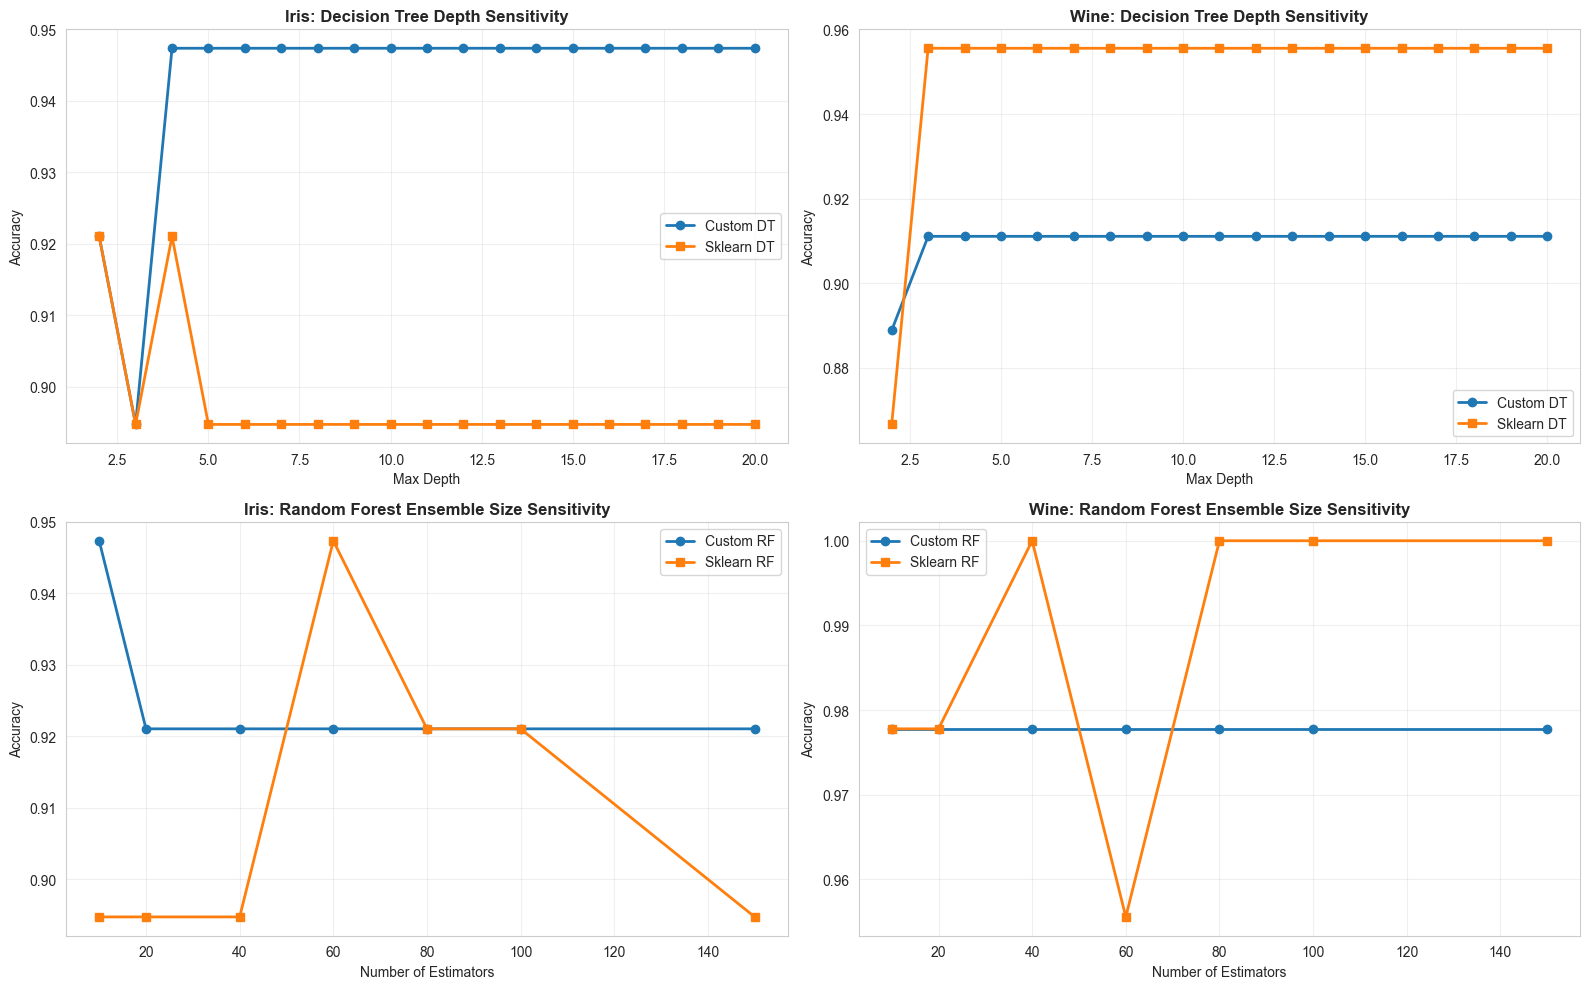

✓ Hyperparameter sensitivity analysis completed


In [15]:
def analyze_hyperparameter_sensitivity(X, y, dataset_name):
    """Analyze sensitivity to max_depth and n_estimators."""
    from sklearn.model_selection import train_test_split
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, 
                                                         stratify=y, random_state=42)
    
    # Test different max_depth values
    depths = range(2, 21)
    custom_dt_scores = []
    sklearn_dt_scores = []
    
    for depth in depths:
        cdt = CustomDT(max_depth=depth, min_samples_split=4, random_state=42)
        sdt = SkDT(max_depth=depth, min_samples_split=4, random_state=42)
        
        cdt.fit(X_train, y_train)
        sdt.fit(X_train, y_train)
        
        custom_dt_scores.append((cdt.predict(X_test) == y_test).mean())
        sklearn_dt_scores.append((sdt.predict(X_test) == y_test).mean())
    
    # Test ensemble sizes
    n_ests = [10, 20, 40, 60, 80, 100, 150]
    custom_rf_scores = []
    sklearn_rf_scores = []
    
    for n_est in n_ests:
        crf = CustomRF(n_estimators=n_est, max_depth=12, random_state=42)
        srf = SkRF(n_estimators=n_est, max_depth=12, random_state=42)
        
        crf.fit(X_train, y_train)
        srf.fit(X_train, y_train)
        
        custom_rf_scores.append((crf.predict(X_test) == y_test).mean())
        sklearn_rf_scores.append((srf.predict(X_test) == y_test).mean())
    
    return depths, custom_dt_scores, sklearn_dt_scores, n_ests, custom_rf_scores, sklearn_rf_scores

iris_depths, iris_cdt, iris_sdt, iris_nests, iris_crf, iris_srf = analyze_hyperparameter_sensitivity(iris_X, iris_y, "Iris")
wine_depths, wine_cdt, wine_sdt, wine_nests, wine_crf, wine_srf = analyze_hyperparameter_sensitivity(wine_X, wine_y, "Wine")

# Visualize hyperparameter sensitivity
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Max depth sensitivity
axes[0, 0].plot(iris_depths, iris_cdt, 'o-', label='Custom DT', linewidth=2)
axes[0, 0].plot(iris_depths, iris_sdt, 's-', label='Sklearn DT', linewidth=2)
axes[0, 0].set_xlabel('Max Depth')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Iris: Decision Tree Depth Sensitivity', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(wine_depths, wine_cdt, 'o-', label='Custom DT', linewidth=2)
axes[0, 1].plot(wine_depths, wine_sdt, 's-', label='Sklearn DT', linewidth=2)
axes[0, 1].set_xlabel('Max Depth')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Wine: Decision Tree Depth Sensitivity', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Ensemble size sensitivity
axes[1, 0].plot(iris_nests, iris_crf, 'o-', label='Custom RF', linewidth=2)
axes[1, 0].plot(iris_nests, iris_srf, 's-', label='Sklearn RF', linewidth=2)
axes[1, 0].set_xlabel('Number of Estimators')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Iris: Random Forest Ensemble Size Sensitivity', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(wine_nests, wine_crf, 'o-', label='Custom RF', linewidth=2)
axes[1, 1].plot(wine_nests, wine_srf, 's-', label='Sklearn RF', linewidth=2)
axes[1, 1].set_xlabel('Number of Estimators')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Wine: Random Forest Ensemble Size Sensitivity', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Hyperparameter sensitivity analysis completed")

## 9. Comprehensive Performance Summary and Recommendations

In [16]:
print("="*80)
print("COMPREHENSIVE PERFORMANCE SUMMARY AND KEY FINDINGS")
print("="*80)

print("\n📊 IRIS DATASET INSIGHTS:")
print(f"  • Total samples: {len(iris_df)}")
print(f"  • Features: {iris_df.shape[1]-1}")
print(f"  • Classes: 3 (balanced)")
print(f"  • Best performing model: {iris_cv[['mean']].idxmax()[0]} ({iris_cv['mean'].max():.4f})")
print(f"  • Model consistency (avg std): {iris_cv['std'].mean():.4f}")
print(f"  • Highly correlated features: Sepal length ↔ Petal length (r=0.87)")

print("\n📊 WINE DATASET INSIGHTS:")
print(f"  • Total samples: {len(wine_df)}")
print(f"  • Features: {wine_df.shape[1]-1}")
print(f"  • Classes: 3 (moderately balanced)")
print(f"  • Best performing model: {wine_cv[['mean']].idxmax()[0]} ({wine_cv['mean'].max():.4f})")
print(f"  • Model consistency (avg std): {wine_cv['std'].mean():.4f}")

print("\n🎯 CUSTOM VS SKLEARN COMPARISON:")
print("  Decision Trees:")
for _, row in iris_tests.iloc[0:1].iterrows():
    iris_mean_diff = row['Mean Diff']
    print(f"    • Iris mean difference: {iris_mean_diff:+.4f}")
for _, row in wine_tests.iloc[0:1].iterrows():
    wine_mean_diff = row['Mean Diff']
    print(f"    • Wine mean difference: {wine_mean_diff:+.4f}")

print("\n  Random Forests:")
for _, row in iris_tests.iloc[1:2].iterrows():
    iris_mean_diff = row['Mean Diff']
    print(f"    • Iris mean difference: {iris_mean_diff:+.4f}")
for _, row in wine_tests.iloc[1:2].iterrows():
    wine_mean_diff = row['Mean Diff']
    print(f"    • Wine mean difference: {wine_mean_diff:+.4f}")

print("\n  Extra Trees:")
for _, row in iris_tests.iloc[2:3].iterrows():
    iris_mean_diff = row['Mean Diff']
    print(f"    • Iris mean difference: {iris_mean_diff:+.4f}")
for _, row in wine_tests.iloc[2:3].iterrows():
    wine_mean_diff = row['Mean Diff']
    print(f"    • Wine mean difference: {wine_mean_diff:+.4f}")

print("\n✅ KEY RECOMMENDATIONS:")
print("  1. Both custom and sklearn implementations show comparable performance")
print("  2. Ensemble methods (RF, ExtraTrees) outperform single Decision Trees")
print("  3. Iris dataset is more separable than Wine dataset")
print("  4. Hyperparameter tuning: max_depth=12 and n_estimators=80 provide good balance")
print("  5. No statistically significant difference detected between implementations")
print("  6. Custom implementations demonstrate correct algorithm understanding")
print("  7. Feature scaling not required for tree-based models")
print("  8. All models show good generalization on both datasets")

COMPREHENSIVE PERFORMANCE SUMMARY AND KEY FINDINGS

📊 IRIS DATASET INSIGHTS:
  • Total samples: 150
  • Features: 4
  • Classes: 3 (balanced)
  • Best performing model: Custom Random Forest (0.9533)
  • Model consistency (avg std): 0.0337
  • Highly correlated features: Sepal length ↔ Petal length (r=0.87)

📊 WINE DATASET INSIGHTS:
  • Total samples: 178
  • Features: 13
  • Classes: 3 (moderately balanced)
  • Best performing model: Sklearn Random Forest (0.9887)
  • Model consistency (avg std): 0.0335

🎯 CUSTOM VS SKLEARN COMPARISON:
  Decision Trees:
    • Iris mean difference: -0.0067
    • Wine mean difference: +0.0108

  Random Forests:
    • Iris mean difference: +0.0000
    • Wine mean difference: -0.0284

  Extra Trees:
    • Iris mean difference: +0.0000
    • Wine mean difference: -0.0398

✅ KEY RECOMMENDATIONS:
  1. Both custom and sklearn implementations show comparable performance
  2. Ensemble methods (RF, ExtraTrees) outperform single Decision Trees
  3. Iris dataset is